# EBU Screening Tool — metal centres, linkers, additives, solvation & 3D viewer

A configurable front-end to the `ebu_toolkit` pipeline. Edit the **CONFIG** cells, run top-to-bottom, and inspect / visualize the generated extended building units (EBUs).

**Pipeline layers (all GFN2-xTB, screening-grade):**
1. **Enumerate** candidate EBUs (geometry + QC) for your metals × linkers × additives.
2. **Rank** them by formation energy — gas phase or implicit solvent.
3. **Solvation sweep** — explicit-shell + ALPB continuum over water/ethanol/DMF combinations, giving nucleation driving force and additive-sequestration margin.
4. **Visualize** any generated model in 3D.

**Requirements:** `rdkit`, `ase`, `tblite` (GFN2-xTB), `py3Dmol` (3D), `pandas`, `matplotlib`.
```
pip install rdkit ase tblite py3Dmol pandas matplotlib
```


## 0 · Setup & dependency check

Run this first. If anything is missing it prints the exact install command for your platform — install, then **restart the kernel**. `tblite` (the GFN2-xTB engine) is the one that trips people up: it is pip-installable on Linux/macOS but on **Windows** it must come from conda-forge.

In [9]:
import importlib, platform
_WIN = platform.system() == 'Windows'
_REQ = {
    'rdkit'     : 'pip install rdkit',
    'ase'       : 'pip install ase',
    'tblite'    : ('conda install -c conda-forge tblite-python' if _WIN else 'pip install tblite'),
    'pandas'    : 'pip install pandas',
    'matplotlib': 'pip install matplotlib',
    'py3Dmol'   : 'pip install py3Dmol       # 3D viewer (section 5)',
    'ipywidgets': 'pip install ipywidgets     # optional: dropdown selector',
}
missing = []
for mod, cmd in _REQ.items():
    try: importlib.import_module(mod)
    except ImportError: missing.append((mod, cmd))
if missing:
    print('Missing packages — install these, then RESTART THE KERNEL:\n')
    for m, c in missing: print(f'  {m:11s} ->  {c}')
    if _WIN and any(m=='tblite' for m,_ in missing):
        print('\n  (On Windows pip has no tblite wheels — use the conda-forge command above.)')
else:
    print('All core dependencies present.')

All core dependencies present.


In [10]:
import warnings; warnings.filterwarnings('ignore')
import pandas as pd, matplotlib.pyplot as plt
import ebu_toolkit as T
from ebu_toolkit import LIGAND_LIBRARY, SOLVENTS
pd.set_option('display.max_colwidth', 60); pd.set_option('display.width', 160)
print('Built-in ligand library :', ', '.join(LIGAND_LIBRARY))
print('Built-in solvents        :', ', '.join(SOLVENTS))
print('Add your own any time, e.g.:  LIGAND_LIBRARY[\'NDC\'] = \'OC(=O)c1ccc2cc(C(=O)O)ccc2c1\'')

Built-in ligand library : BTC, BDC, EDTA, EDDA, bipy
Built-in solvents        : water, ethanol, dmf
Add your own any time, e.g.:  LIGAND_LIBRARY['NDC'] = 'OC(=O)c1ccc2cc(C(=O)O)ccc2c1'


## 1 · CONFIG — what to build  ✏️

Edit this cell. Metals may be plain symbols (default oxidation state) or `(symbol, charge)` tuples.
Linkers/additives are names from the library above, or `'Name:SMILES'` to define inline.

`additive_mode`: `'subsets'` builds linker-only **plus every additive combination** (best for competition studies) · `'all'` uses all additives together · `'none'` ignores additives.

In [3]:
METALS       = [('Ni', 2), 'Cu']      # e.g. 'Cu', ('Co',2), 'Zr' ...
LINKERS      = ['BTC']                 # framework linker(s)
ADDITIVES    = ['EDTA', 'EDDA']        # chelating / modulating additives
ADDITIVE_MODE = 'subsets'              # 'subsets' | 'all' | 'none'

MAX_COPIES   = 4      # max copies of each ligand species per metal
CLASH_SCALE  = 0.65   # QC clash tolerance (lower = more permissive; Fe often needs 0.60)
SPIN_MODE    = 'highspin'   # 'highspin' (d-electron based) | 'auto' (minimal spin)

## 2 · Enumerate candidate EBUs

In [4]:
models_df = T.enumerate_models(
    metals=METALS, linkers=LINKERS, additives=ADDITIVES,
    additive_mode=ADDITIVE_MODE, max_copies=MAX_COPIES,
    clash_scale=CLASH_SCALE, verbose=True)

print(f'\n{len(models_df)} QC-valid models. Counts by metal × scenario:')
display(models_df.groupby(['metal','scenario']).size().rename('n_models').reset_index())
display(models_df.head(20))

[LigandBuilder] 'BTC' | 3 site(s) (1 unique) | 3xcarboxylate_O | donors: [8, 11, 14]
[LigandBuilder] 'EDTA' | 6 site(s) (2 unique) | 2xamine_N, 4xcarboxylate_O | donors: [2, 6, 10, 11, 15, 19]
[LigandBuilder] 'EDDA' | 4 site(s) (2 unique) | 2xcarboxylate_O, 2xamine_N | donors: [0, 4, 7, 11]
[EBUBuilder] Ni(2+) + 1 ligand(s) | 2 M-L bonds | 19 atoms [OK]
[GeometryPlacer] 1 ligand(s) placed as bridging (single-anchor)
[QC] Ni2+_linker_only_BTC[s2]_planar_q-1: INVALID: M-donor O12: 4.28 Ang (target 2.05 +/- 0.6)
[EBUBuilder] Ni(2+) + 1 ligand(s) | 3 M-L bonds | 19 atoms [OK]
[GeometryPlacer] 1 ligand(s) placed as bridging (single-anchor)
[QC] Ni2+_linker_only_BTC[s3]_planar_q-1: INVALID: M-donor O12: 4.28 Ang (target 2.05 +/- 0.6); M-donor O15: 7.30 Ang (target 2.05 +/- 0.6)
[EBUBuilder] Ni(2+) + 2 ligand(s) | 2 M-L bonds | 37 atoms [OK]
XYZ -> tool_outputs\Ni2\Ni2+_linker_only_BTC[s1]_BTC[s1]_planar_q-4.xyz
[EBUBuilder] Ni(2+) + 2 ligand(s) | 3 M-L bonds | 37 atoms [OK]
[GeometryPlacer] 

[17:59:00] UFFTYPER: Unrecognized atom type: He+4 (32)
[17:59:00] UFFTYPER: Unrecognized atom type: He+4 (32)


[QC] Ni2+_EDTA_EDTA[s4]_planar_q-2: INVALID: M-donor O7: 4.99 Ang (target 2.05 +/- 0.6); M-donor N12: 4.43 Ang (target 2.05 +/- 0.6)
[EBUBuilder] Ni(2+) + 1 ligand(s) | 4 M-L bonds | 33 atoms [OK]
[GeometryPlacer] 1 ligand(s) placed as bridging (single-anchor)
[QC] Ni2+_EDTA_EDTA[s4]_tetrahedral_q-2: INVALID: M-donor O7: 4.99 Ang (target 2.05 +/- 0.6); M-donor N12: 4.43 Ang (target 2.05 +/- 0.6)
[EBUBuilder] Ni(2+) + 1 ligand(s) | 5 M-L bonds | 33 atoms [OK]
[GeometryPlacer] 1 ligand(s) placed as bridging (single-anchor)
[QC] Ni2+_EDTA_EDTA[s5]_planar_q-2: INVALID: M-donor O7: 4.99 Ang (target 2.05 +/- 0.6); M-donor N12: 4.43 Ang (target 2.05 +/- 0.6); M-donor O16: 5.56 Ang (target 2.05 +/- 0.6)
[EBUBuilder] Ni(2+) + 1 ligand(s) | 6 M-L bonds | 33 atoms [OK]
[GeometryPlacer] 1 ligand(s) placed as bridging (single-anchor)
[QC] Ni2+_EDTA_EDTA[s6]_octahedral_q-2: INVALID: M-donor O7: 4.99 Ang (target 2.05 +/- 0.6); M-donor N12: 4.43 Ang (target 2.05 +/- 0.6); M-donor O16: 5.56 Ang (target

[17:59:01] UFFTYPER: Unrecognized atom type: He+4 (32)
[17:59:01] UFFTYPER: Unrecognized atom type: He+4 (32)
[17:59:01] UFFTYPER: Unrecognized atom type: He+4 (32)


[QC] Ni2+_EDTA_EDTA[s1]_EDTA[s3]_tetrahedral_q-6: INVALID: clash C9-O42: 0.42 Ang (0.13x vdW sum 3.25); clash O11-C41: 0.66 Ang (0.20x vdW sum 3.25); clash O11-O42: 1.07 Ang (0.35x vdW sum 3.10); clash Ni0-H60: 1.17 Ang (0.37x vdW sum 3.20); clash N3-H60: 1.16 Ang (0.41x vdW sum 2.80); clash C8-O42: 1.48 Ang (0.46x vdW sum 3.25); clash C9-C41: 1.57 Ang (0.46x vdW sum 3.40); clash O11-O43: 1.52 Ang (0.49x vdW sum 3.10)
[EBUBuilder] Ni(2+) + 2 ligand(s) | 4 M-L bonds | 65 atoms [OK]
[GeometryPlacer] 2/2 chelate DG wrap(s) succeeded
[QC] Ni2+_EDTA_EDTA[s2]_EDTA[s2]_planar_q-6: INVALID: clash Ni0-H57: 1.00 Ang (0.31x vdW sum 3.20); clash C5-H57: 1.02 Ang (0.35x vdW sum 2.90); clash O6-C40: 1.23 Ang (0.38x vdW sum 3.25); clash O7-H57: 1.04 Ang (0.38x vdW sum 2.75); clash O6-N35: 1.27 Ang (0.40x vdW sum 3.15); clash Ni0-O6: 1.65 Ang (0.47x vdW sum 3.55); clash H24-O38: 1.32 Ang (0.48x vdW sum 2.75); clash C4-O43: 1.64 Ang (0.51x vdW sum 3.25)
[EBUBuilder] Ni(2+) + 2 ligand(s) | 4 M-L bonds |

...

[GeometryPlacer] 1/1 chelate DG wrap(s) succeeded
[QC] Cu2+_EDTA+EDDA_BTC[s1]_BTC[s1]_BTC[s1]_EDTA[s1]_EDTA[s2]_octahedral_q-15: INVALID: clash H80-H114: 0.50 Ang (0.21x vdW sum 2.40); clash H36-H86: 0.77 Ang (0.32x vdW sum 2.40); clash C28-O74: 1.06 Ang (0.33x vdW sum 3.25); clash O9-C95: 1.10 Ang (0.34x vdW sum 3.25); clash C23-H86: 0.99 Ang (0.34x vdW sum 2.90); clash O27-H76: 0.94 Ang (0.34x vdW sum 2.75); clash C58-H114: 0.98 Ang (0.34x vdW sum 2.90); clash O65-O93: 1.06 Ang (0.34x vdW sum 3.10)
[EBUBuilder] Cu(2+) + 5 ligand(s) | 6 M-L bonds | 119 atoms [OK]
[GeometryPlacer] 1 ligand(s) placed as bridging (single-anchor)
[QC] Cu2+_EDTA+EDDA_BTC[s1]_BTC[s1]_BTC[s2]_EDTA[s1]_EDTA[s1]_octahedral_q-15: INVALID: M-donor O48: 6.57 Ang (target 2.05 +/- 0.6); clash H18-C88: 0.81 Ang (0.28x vdW sum 2.90); clash C6-O96: 1.10 Ang (0.34x vdW sum 3.25); clash C4-H114: 1.05 Ang (0.36x vdW sum 2.90); clash C6-C95: 1.25 Ang (0.37x vdW sum 3.40); clash C1-O96: 1.26 Ang (0.39x vdW sum 3.25); clash

[18:08:14] UFFTYPER: Unrecognized atom type: He+4 (32)


[GeometryPlacer] 1/1 chelate DG wrap(s) succeeded
[QC] Cu2+_EDTA+EDDA_BTC[s1]_BTC[s1]_BTC[s1]_BTC[s1]_EDTA[s2]_octahedral_q-14: INVALID: clash O9-C81: 1.10 Ang (0.34x vdW sum 3.25); clash O45-C76: 1.20 Ang (0.37x vdW sum 3.25); clash O45-C77: 1.27 Ang (0.39x vdW sum 3.25); clash O62-H95: 1.15 Ang (0.42x vdW sum 2.75); clash C43-O78: 1.39 Ang (0.43x vdW sum 3.25); clash O44-O78: 1.37 Ang (0.44x vdW sum 3.10); clash O45-H98: 1.22 Ang (0.44x vdW sum 2.75); clash O9-O82: 1.41 Ang (0.46x vdW sum 3.10)
[EBUBuilder] Cu(2+) + 5 ligand(s) | 6 M-L bonds | 105 atoms [OK]
[GeometryPlacer] 1 ligand(s) placed as bridging (single-anchor)
[QC] Cu2+_EDTA+EDDA_BTC[s1]_BTC[s1]_BTC[s1]_BTC[s2]_EDTA[s1]_octahedral_q-14: INVALID: M-donor O66: 6.24 Ang (target 2.05 +/- 0.6); clash O27-O83: 1.39 Ang (0.45x vdW sum 3.10); clash O66-O92: 1.62 Ang (0.52x vdW sum 3.10); clash C7-O87: 1.72 Ang (0.53x vdW sum 3.25); clash C5-O45: 1.81 Ang (0.56x vdW sum 3.25); clash O66-C89: 1.83 Ang (0.56x vdW sum 3.25); clash C10

,metal,scenario,n_models
0,Cu,EDDA,16
1,Cu,EDTA,6
2,Cu,EDTA+EDDA,19
3,Cu,linker_only,4
4,Ni,EDDA,16
5,Ni,EDTA,6
6,Ni,EDTA+EDDA,19
7,Ni,linker_only,4


,metal,scenario,label,n_atoms,charge,n_bonds,qc_valid
0,Ni,linker_only,Ni2+_linker_only_BTC[s1]_BTC[s1]_planar_q-4,37,-4,2,True
1,Ni,linker_only,Ni2+_linker_only_BTC[s1]_BTC[s1]_BTC[s1]_planar_q-7,55,-7,3,True
2,Ni,linker_only,Ni2+_linker_only_BTC[s1]_BTC[s1]_BTC[s1]_BTC[s1]_planar_...,73,-10,4,True
3,Ni,linker_only,Ni2+_linker_only_BTC[s1]_BTC[s1]_BTC[s1]_BTC[s1]_tetrahe...,73,-10,4,True
4,Ni,EDTA,Ni2+_EDTA_EDTA[s2]_planar_q-2,33,-2,2,True
5,Ni,EDTA,Ni2+_EDTA_EDTA[s3]_planar_q-2,33,-2,3,True
6,Ni,EDTA,Ni2+_EDTA_BTC[s1]_BTC[s1]_planar_q-4,37,-4,2,True
7,Ni,EDTA,Ni2+_EDTA_BTC[s1]_BTC[s1]_BTC[s1]_planar_q-7,55,-7,3,True
8,Ni,EDTA,Ni2+_EDTA_BTC[s1]_BTC[s1]_BTC[s1]_BTC[s1]_planar_q-10,73,-10,4,True
9,Ni,EDTA,Ni2+_EDTA_BTC[s1]_BTC[s1]_BTC[s1]_BTC[s1]_tetrahedral_q-10,73,-10,4,True


## 3 · Rank by formation energy

`solvent=None` → gas phase.  `solvent='water'|'ethanol'|'dmf'` → implicit ALPB continuum.
Lower `E_form` = more stable (thermodynamic sink); `E_form_per_bond` exposes bond *quality* vs bond *count*.

In [5]:
SOLVENT_FOR_RANKING = None    # None (gas) | 'water' | 'ethanol' | 'dmf'

ranked = T.formation_energies(solvent=SOLVENT_FOR_RANKING, spin_mode=SPIN_MODE,
                              relax=True, steps=60, verbose=True)
display(ranked.head(25))

[LigandBuilder] 'BTC' | 3 site(s) (1 unique) | 3xcarboxylate_O | donors: [8, 11, 14]
[1/90] Ni2+_linker_only_BTC[s1]_BTC[s1]_planar_q-4      Ef= -36.185 eV
[2/90] Ni2+_linker_only_BTC[s1]_BTC[s1]_BTC[s1]_planar_ Ef= -21.399 eV
[3/90] Ni2+_linker_only_BTC[s1]_BTC[s1]_BTC[s1]_BTC[s1] Ef=   3.401 eV
[4/90] Ni2+_linker_only_BTC[s1]_BTC[s1]_BTC[s1]_BTC[s1] Ef=   3.167 eV
[LigandBuilder] 'EDTA' | 6 site(s) (2 unique) | 2xamine_N, 4xcarboxylate_O | donors: [2, 6, 10, 11, 15, 19]
[5/90] Ni2+_EDTA_EDTA[s2]_planar_q-2                    Ef= -42.748 eV
[6/90] Ni2+_EDTA_EDTA[s3]_planar_q-2                    Ef= -43.483 eV
[7/90] Ni2+_EDTA_BTC[s1]_BTC[s1]_planar_q-4             Ef= -36.188 eV
[8/90] Ni2+_EDTA_BTC[s1]_BTC[s1]_BTC[s1]_planar_q-7     Ef= -21.399 eV
[9/90] Ni2+_EDTA_BTC[s1]_BTC[s1]_BTC[s1]_BTC[s1]_planar Ef=   3.401 eV
[10/90] Ni2+_EDTA_BTC[s1]_BTC[s1]_BTC[s1]_BTC[s1]_tetrah Ef=   3.167 eV
[LigandBuilder] 'EDDA' | 4 site(s) (2 unique) | 2xcarboxylate_O, 2xamine_N | donors: [0, 4, 7, 1

,label,metal,scenario,charge,n_bonds,E_form_eV,E_form_per_bond_eV
0,Ni2+_EDTA_EDTA[s3]_planar_q-2,Ni,EDTA,-2,3,-43.483,-14.494
1,Ni2+_EDTA+EDDA_EDTA[s3]_planar_q-2,Ni,EDTA+EDDA,-2,3,-43.483,-14.494
2,Ni2+_EDTA+EDDA_EDTA[s2]_planar_q-2,Ni,EDTA+EDDA,-2,2,-42.748,-21.374
3,Ni2+_EDTA_EDTA[s2]_planar_q-2,Ni,EDTA,-2,2,-42.748,-21.374
4,Cu2+_EDTA_EDTA[s2]_planar_q-2,Cu,EDTA,-2,2,-40.989,-20.494
5,Cu2+_EDTA+EDDA_EDTA[s2]_planar_q-2,Cu,EDTA+EDDA,-2,2,-40.989,-20.494
6,Cu2+_EDTA+EDDA_EDTA[s3]_planar_q-2,Cu,EDTA+EDDA,-2,3,-40.720,-13.573
7,Cu2+_EDTA_EDTA[s3]_planar_q-2,Cu,EDTA,-2,3,-40.720,-13.573
8,Ni2+_EDTA+EDDA_EDTA[s3]_EDDA[s1]_tetrahedral_q-4,Ni,EDTA+EDDA,-4,4,-39.189,-9.797
9,Cu2+_EDTA+EDDA_EDTA[s3]_EDDA[s1]_tetrahedral_q-4,Cu,EDTA+EDDA,-4,4,-36.545,-9.136


KeyError: 'chelation_extent'

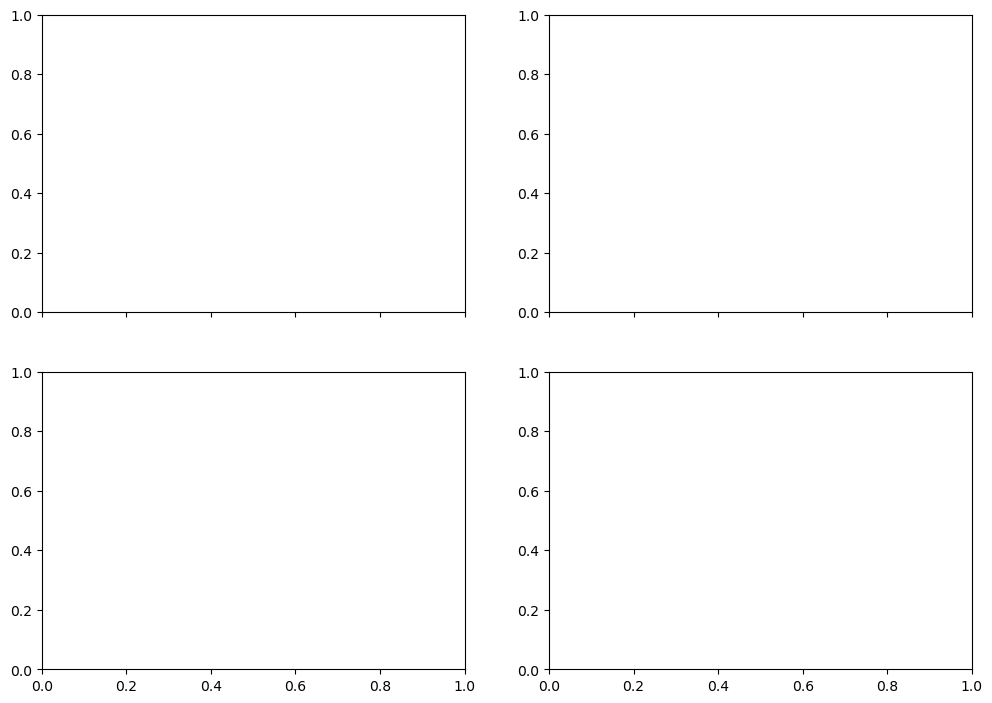

In [11]:
# Formation energy vs CHELATION EXTENT (fraction of the metal's bonds from the additive).
# x = 0 -> pure framework/linker node ; x = 1 -> metal fully wrapped by chelator.
# Top row = total E_form (thermodynamic sink) ; bottom row = per-bond E_form (bond quality).
# Marker size = coordination number ; colour = scenario ; green dashed = framework node.
import numpy as np
df = ranked.dropna(subset=['E_form_eV']).copy()
metals = list(df['metal'].unique())
scen_list = sorted(df['scenario'].unique())
palette = dict(zip(scen_list, (plt.cm.tab10.colors * 3)[:len(scen_list)]))
metrics = [('E_form_eV', 'total  E_form (eV)'), ('E_form_per_bond_eV', 'per-bond  E_form (eV)')]

fig, axes = plt.subplots(2, len(metals), figsize=(6*len(metals), 8.5), squeeze=False, sharex=True)
for col, metal in enumerate(metals):
    g = df[df.metal == metal]
    base = g[g['chelation_extent'] == 0]              # pure-linker framework nodes
    for row, (mkey, mlab) in enumerate(metrics):
        ax = axes[row][col]
        node = base[mkey].min() if len(base) else np.nan
        if node == node:
            ax.axhline(node, ls='--', color='green', lw=1.2, zorder=1)
        for scen, gs in g.groupby('scenario'):
            jit = np.random.default_rng(abs(hash(scen)) % 999).normal(0, 0.008, len(gs))
            ax.scatter(gs['chelation_extent'] + jit, gs[mkey],
                       s=30 + 26*gs['n_bonds'], color=palette[scen], edgecolor='k',
                       linewidth=0.4, alpha=0.82, zorder=3,
                       label=scen if row == 0 else None)
        ax.set_ylabel(mlab); ax.grid(alpha=0.25); ax.invert_yaxis()
        if row == 0:
            ax.set_title(f'{metal}   (framework node dashed)')
            ax.legend(fontsize=7, title='scenario')
        else:
            ax.set_xlabel('chelation extent  (fraction of metal bonds from additive)\n'
                          '0 = pure linker node   →   1 = fully chelated')
    axes[0][col].set_xlim(-0.06, 1.06)
fig.suptitle('Formation energy vs chelation extent   (marker size = coordination number)', y=1.0)
plt.tight_layout(); plt.show()

## 4 · Solvation sweep (explicit shell + ALPB continuum)

Completes each metal's octahedral sphere with explicit solvent (equal-ratio combinations of water/ethanol/DMF), wraps the bulk in ALPB, and reports two decision metrics per solvent system:

* **nucleation_dG** = E_form(node) − E_form(solvated ion): *negative → framework beats the dissolved ion* (metal leaves solution to build framework).
* **seq_margin** = E_form(chelator complex) − E_form(node): *negative → the additive sequesters the metal* (competes with the framework).

In [17]:
SOLV_METALS   = METALS
SOLV_LINKER   = 'BTC'
SOLV_CHELATOR = 'EDTA'
SOLV_SYSTEMS  = ['water','ethanol','dmf','water+ethanol','water+dmf','ethanol+dmf','water+ethanol+dmf']

solv_df = T.solvation_sweep(SOLV_METALS, linker=SOLV_LINKER, chelator=SOLV_CHELATOR,
                            systems=SOLV_SYSTEMS, spin_mode=SPIN_MODE, steps=25)
display(solv_df)

[LigandBuilder] 'BTC' | 3 site(s) (1 unique) | 3xcarboxylate_O | donors: [0, 8, 13]
[LigandBuilder] 'BTC' | 3 site(s) (1 unique) | 3xcarboxylate_O | donors: [0, 8, 13]
[LigandBuilder] 'EDTA' | 6 site(s) (2 unique) | 2xamine_N, 4xcarboxylate_O | donors: [2, 6, 10, 11, 15, 19]
[LigandBuilder] 'EDTA' | 6 site(s) (2 unique) | 2xamine_N, 4xcarboxylate_O | donors: [2, 6, 10, 11, 15, 19]
[LigandBuilder] 'BTC' | 3 site(s) (1 unique) | 3xcarboxylate_O | donors: [0, 8, 13]
[LigandBuilder] 'EDTA' | 6 site(s) (2 unique) | 2xamine_N, 4xcarboxylate_O | donors: [2, 6, 10, 11, 15, 19]
[LigandBuilder] 'BTC' | 3 site(s) (1 unique) | 3xcarboxylate_O | donors: [0, 8, 13]
[LigandBuilder] 'BTC' | 3 site(s) (1 unique) | 3xcarboxylate_O | donors: [0, 8, 13]
[LigandBuilder] 'EDTA' | 6 site(s) (2 unique) | 2xamine_N, 4xcarboxylate_O | donors: [2, 6, 10, 11, 15, 19]
[EBUBuilder] Co(2+) + 1 ligand(s) | 6 M-L bonds | 33 atoms [OK]
[GeometryPlacer] 1/1 chelate DG wrap(s) succeeded
[LigandBuilder] 'EDTA' | 6 site(s)

[14:37:38] UFFTYPER: Unrecognized atom type: He+4 (32)


Co water                nucleation= -1.04  seq_margin= -0.44
[LigandBuilder] 'BTC' | 3 site(s) (1 unique) | 3xcarboxylate_O | donors: [0, 8, 13]
[LigandBuilder] 'BTC' | 3 site(s) (1 unique) | 3xcarboxylate_O | donors: [0, 8, 13]
[LigandBuilder] 'EDTA' | 6 site(s) (2 unique) | 2xamine_N, 4xcarboxylate_O | donors: [2, 6, 10, 11, 15, 19]
[EBUBuilder] Co(2+) + 1 ligand(s) | 6 M-L bonds | 33 atoms [OK]
[GeometryPlacer] 1/1 chelate DG wrap(s) succeeded
[LigandBuilder] 'EDTA' | 6 site(s) (2 unique) | 2xamine_N, 4xcarboxylate_O | donors: [2, 6, 10, 11, 15, 19]


[14:38:13] UFFTYPER: Unrecognized atom type: He+4 (32)


Co ethanol              nucleation= -3.31  seq_margin= -0.24
[LigandBuilder] 'BTC' | 3 site(s) (1 unique) | 3xcarboxylate_O | donors: [0, 8, 13]
[LigandBuilder] 'BTC' | 3 site(s) (1 unique) | 3xcarboxylate_O | donors: [0, 8, 13]
[LigandBuilder] 'EDTA' | 6 site(s) (2 unique) | 2xamine_N, 4xcarboxylate_O | donors: [2, 6, 10, 11, 15, 19]
[EBUBuilder] Co(2+) + 1 ligand(s) | 6 M-L bonds | 33 atoms [OK]
[GeometryPlacer] 1/1 chelate DG wrap(s) succeeded
[LigandBuilder] 'EDTA' | 6 site(s) (2 unique) | 2xamine_N, 4xcarboxylate_O | donors: [2, 6, 10, 11, 15, 19]


...

[14:48:02] UFFTYPER: Unrecognized atom type: He+4 (32)


Cu ethanol+dmf          nucleation= -2.34  seq_margin= -0.96
[LigandBuilder] 'BTC' | 3 site(s) (1 unique) | 3xcarboxylate_O | donors: [0, 8, 13]
[LigandBuilder] 'BTC' | 3 site(s) (1 unique) | 3xcarboxylate_O | donors: [0, 8, 13]
[LigandBuilder] 'EDTA' | 6 site(s) (2 unique) | 2xamine_N, 4xcarboxylate_O | donors: [2, 6, 10, 11, 15, 19]
[EBUBuilder] Cu(2+) + 1 ligand(s) | 6 M-L bonds | 33 atoms [OK]
[GeometryPlacer] 1/1 chelate DG wrap(s) succeeded


[14:48:43] UFFTYPER: Unrecognized atom type: He+4 (32)


[LigandBuilder] 'EDTA' | 6 site(s) (2 unique) | 2xamine_N, 4xcarboxylate_O | donors: [2, 6, 10, 11, 15, 19]
Cu water+ethanol+dmf    nucleation= -1.47  seq_margin= -1.29


,metal,system,Ef_ion,Ef_node,Ef_chelator,nucleation_dG,seq_margin
0,Co,water,-14.67,-15.71,-16.15,-1.04,-0.44
1,Co,ethanol,-15.04,-18.34,-18.59,-3.31,-0.24
2,Co,dmf,-18.68,-21.27,-21.36,-2.59,-0.10
3,Co,water+ethanol,-14.92,-16.94,-17.37,-2.02,-0.43
4,Co,water+dmf,-16.44,-18.85,-18.76,-2.41,0.09
5,Co,ethanol+dmf,-17.00,-19.39,-19.97,-2.39,-0.59
6,Co,water+ethanol+dmf,-16.18,-18.41,-18.70,-2.22,-0.29
7,Fe,water,-10.75,-11.27,-9.64,-0.53,1.64
8,Fe,ethanol,-10.22,-12.95,-12.07,-2.73,0.88
9,Fe,dmf,-12.34,-13.98,-13.64,-1.64,0.34


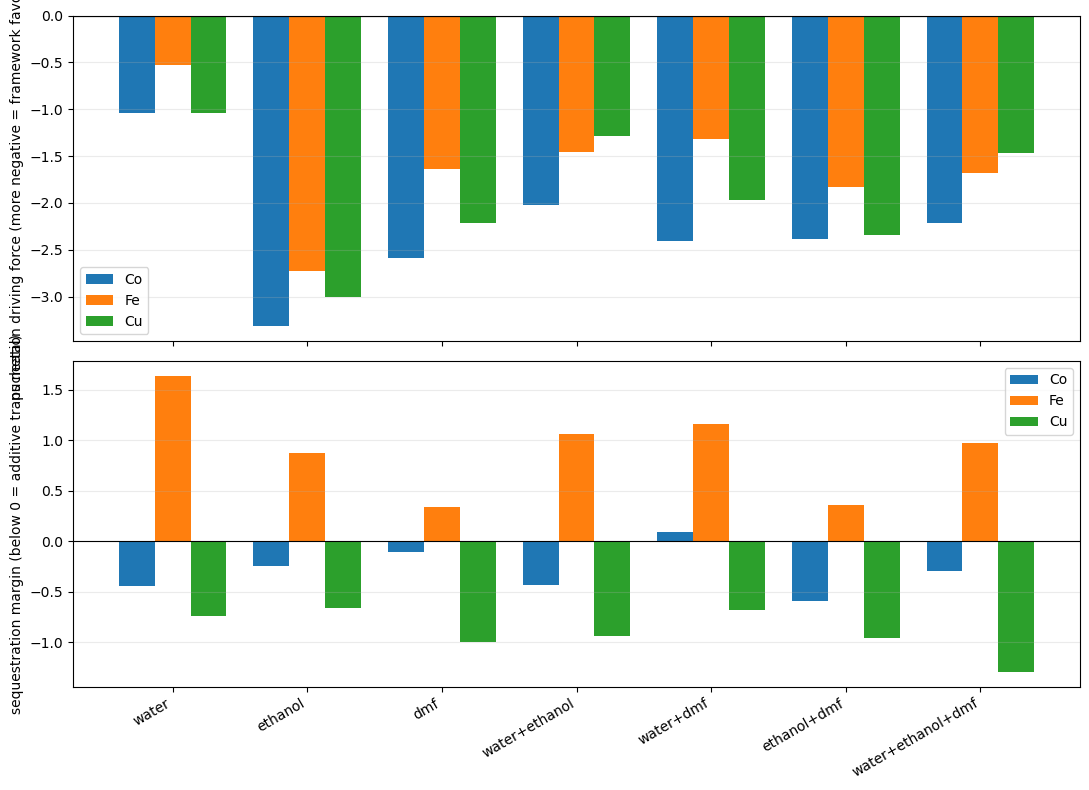

In [18]:
# Two-metric bar chart across solvent systems
fig,(a1,a2)=plt.subplots(2,1,figsize=(11,8),sharex=True)
import numpy as np
mets=solv_df['metal'].unique(); x=np.arange(len(SOLV_SYSTEMS)); w=.8/len(mets)
for j,mt in enumerate(mets):
    g=solv_df[solv_df.metal==mt].set_index('system').reindex(SOLV_SYSTEMS)
    a1.bar(x+j*w, g['nucleation_dG'], w, label=mt)
    a2.bar(x+j*w, g['seq_margin'],   w, label=mt)
for a,t in [(a1,'nucleation driving force (more negative = framework favoured)'),
            (a2,'sequestration margin (below 0 = additive traps metal)')]:
    a.axhline(0,color='k',lw=.8); a.set_ylabel(t); a.legend(); a.grid(axis='y',alpha=.25)
a2.set_xticks(x+w*(len(mets)-1)/2); a2.set_xticklabels(SOLV_SYSTEMS,rotation=30,ha='right')
plt.tight_layout(); plt.show()

## 5 · 3D viewer  🔬

Pick any generated model to render. Run the cell; use the dropdowns (needs `ipywidgets`) or call `T.view_model('<label>')` directly.
`T.list_models(metal=..., scenario=..., contains=...)` filters the available labels.

In [7]:
labels = T.list_models()
print(len(labels), 'models available. Examples:'); [print('  ', l) for l in labels[:8]]

try:
    import ipywidgets as W
    from IPython.display import display, clear_output
    metals = sorted({T.MODELS[l]['metal'] for l in labels})
    dd_metal = W.Dropdown(options=['(all)']+metals, description='Metal:')
    dd_model = W.Dropdown(options=labels, description='Model:', layout=W.Layout(width='70%'))
    out = W.Output()
    def _refresh(*_):
        m=dd_metal.value
        dd_model.options=[l for l in labels if m=='(all)' or T.MODELS[l]['metal']==m]
    def _show(*_):
        with out:
            clear_output(wait=True)
            if dd_model.value: T.view_model(dd_model.value)
    dd_metal.observe(_refresh,'value'); dd_model.observe(_show,'value')
    display(W.VBox([dd_metal, dd_model, out])); _show()
except ImportError:
    print('\nipywidgets not installed — call directly, e.g.:')
    print("   T.view_model('%s')" % (labels[0] if labels else '<label>'))

90 models available. Examples:
   Ni2+_linker_only_BTC[s1]_BTC[s1]_planar_q-4
   Ni2+_linker_only_BTC[s1]_BTC[s1]_BTC[s1]_planar_q-7
   Ni2+_linker_only_BTC[s1]_BTC[s1]_BTC[s1]_BTC[s1]_planar_q-10
   Ni2+_linker_only_BTC[s1]_BTC[s1]_BTC[s1]_BTC[s1]_tetrahedral_q-10
   Ni2+_EDTA_EDTA[s2]_planar_q-2
   Ni2+_EDTA_EDTA[s3]_planar_q-2
   Ni2+_EDTA_BTC[s1]_BTC[s1]_planar_q-4
   Ni2+_EDTA_BTC[s1]_BTC[s1]_BTC[s1]_planar_q-7


In [10]:
# Direct call (works without ipywidgets):
T.view_model(T.list_models()[0], spin=True)

3Dmol.js failed to load for some reason. Please check your browser console for error messages.

3Dmol.js failed to load for some reason. Please check your browser console for error messages.

---
### Notes
* All energies are **screening-grade GFN2-xTB** — trust *relative* rankings and the *direction/magnitude* of solvent effects, not absolute values. See the report `.md` files for full caveats.
* Extend the tool by adding entries to `LIGAND_LIBRARY` / `SOLVENTS`, or new metals to `METALS`. High-spin multiplicities for uncommon ions can be added to `ebu_toolkit._D_ELECTRONS`.
* Generated `.xyz` files are written under `tool_outputs/<metal>/` and can be opened in any molecular viewer.